# Using EcoFOCIpy to process raw field data

## Mooring / Timeseries Data

Basic workflow for each instrument grouping is *(initial archive level)*:
- Parse data from raw files into pandas dataframe
- output initial files (pandas->csv) **ERDDAP NRT** when no meta data is added

Convert to xarray dataframe for all following work *(working or final data level):
- TODO: Add metadata from instrument yaml files and/or header info
- ingest metadata from deployment/recovery records or cast logs
- process data beyond simple file translate
- apply any calibrations or corrections
    + field corrections
    + offsets
    + instrument compensations
    + some QC were available... this would be old-school simple bounds mostly
- adjust time bounds and sample frequency (xarray dataframe)
- save as CF netcdf via xarray: so many of the steps above are optional
    + **ERDDAP NRT** if no corrections, offsets or time bounds are applied but some meta data is
    + **Working and awaiting QC** has no ERDDAP representation and is a holding spot
    + **ERDDAP Final** fully calibrated, qc'd and populated with meta information

Plot for preview and QC
- preview images (indiv and/or collectively)
- manual qc process
- automated qc process ML/AI

Further refinenments for ERDDAP hosting:


## Example below is for Meterological Data as it comes off the TELOS/FLOT system.

Future processing of this instrument can be a simplified (no markdown) process which can be archived so that the procedure can be traced or updated

In [1]:
import pandas as pd
import yaml

import EcoFOCIpy.io.sbe_parser as sbe_parser #<- instrument specific
import EcoFOCIpy.io.ncCFsave as ncCFsave
import EcoFOCIpy.metaconfig.load_config as load_config

The sample_data_dir should be included in the github package but may not be included in the pip install of the package

## Simple Processing - first step

In [2]:
sample_data_dir = '/Users/bell/Programs/EcoFOCIpy/'
user_data_dir = '/Users/bell/ecoraid/2025/Moorings/25bspr2a/'

In [3]:
###############################################################
# edit to point to {instrument sepcific} raw datafile 
datafile = user_data_dir+'initial_archive/prawler/25BSPR-2A_preliminary_Met.10min.csv'
instrument = 'met_telos'
mooring_meta_file = user_data_dir+'logs/25BSPR-2A.yaml'
inst_meta_file = sample_data_dir+'staticdata/instr_metaconfig/telos_wx_cf.yaml'
institution_meta_file = sample_data_dir+'staticdata/institutional_meta_example.yaml' #include uaf?
inst_shortname = 'met_telos'
###############################################################


#init and load data
#10min or 1hr data are available usually from telos driven met packages
met_df = pd.read_csv(datafile,parse_dates=True,index_col='time (UTC)')

In [4]:
met_df

,PAR,Pitch,Roll,Temperature,BaroPres,BP_Std,Air_Temp,Air_Temp_Std,RH,RH_Std,ShortWaveRad,U_wind,Uwind_Std,V_wind,Vwind_Std,Wind_Speed,Gust,Compass,wind_speed,wind_from_direction
time (UTC),,,,,,,,,,,,,,,,,,,,
2025-04-30 00:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,481.39,-0.1,0.4,-1.6,0.4,1.7,2.3,346.3,1.603122,3.576334
2025-04-30 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,373.32,0.5,0.4,-1.3,0.4,1.4,1.7,341.5,1.392839,338.962489
2025-04-30 00:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,353.31,0.6,0.3,-0.9,0.3,1.2,1.6,328.2,1.081665,326.309932
2025-04-30 00:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,335.75,0.8,0.5,-1.0,0.3,1.4,2.0,340.9,1.280625,321.340192
2025-04-30 01:00:00,795.85,0.25,-1.37,13.23,991.94,0.00,4.16,0.03,90.94,0.0,425.28,0.7,0.4,-1.0,0.4,1.3,1.7,3.3,1.220656,325.007980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,516.95,0.0,0.8,-1.4,0.8,1.7,2.8,133.9,1.400000,360.000000
2025-09-01 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,719.60,-0.8,0.8,-0.8,0.6,1.4,2.7,165.6,1.131371,45.000000
2025-09-01 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,471.98,-1.2,0.7,-0.8,0.5,1.6,2.4,164.1,1.442221,56.309932


In [5]:
#wrap the plot in image settings for visual appeal
# may be able to make this cleaner or just a preset
%run '../../../settings/mpl_plot_settings.py'

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, WeekdayLocator, MonthLocator, DayLocator, HourLocator, DateFormatter
import matplotlib.ticker as ticker


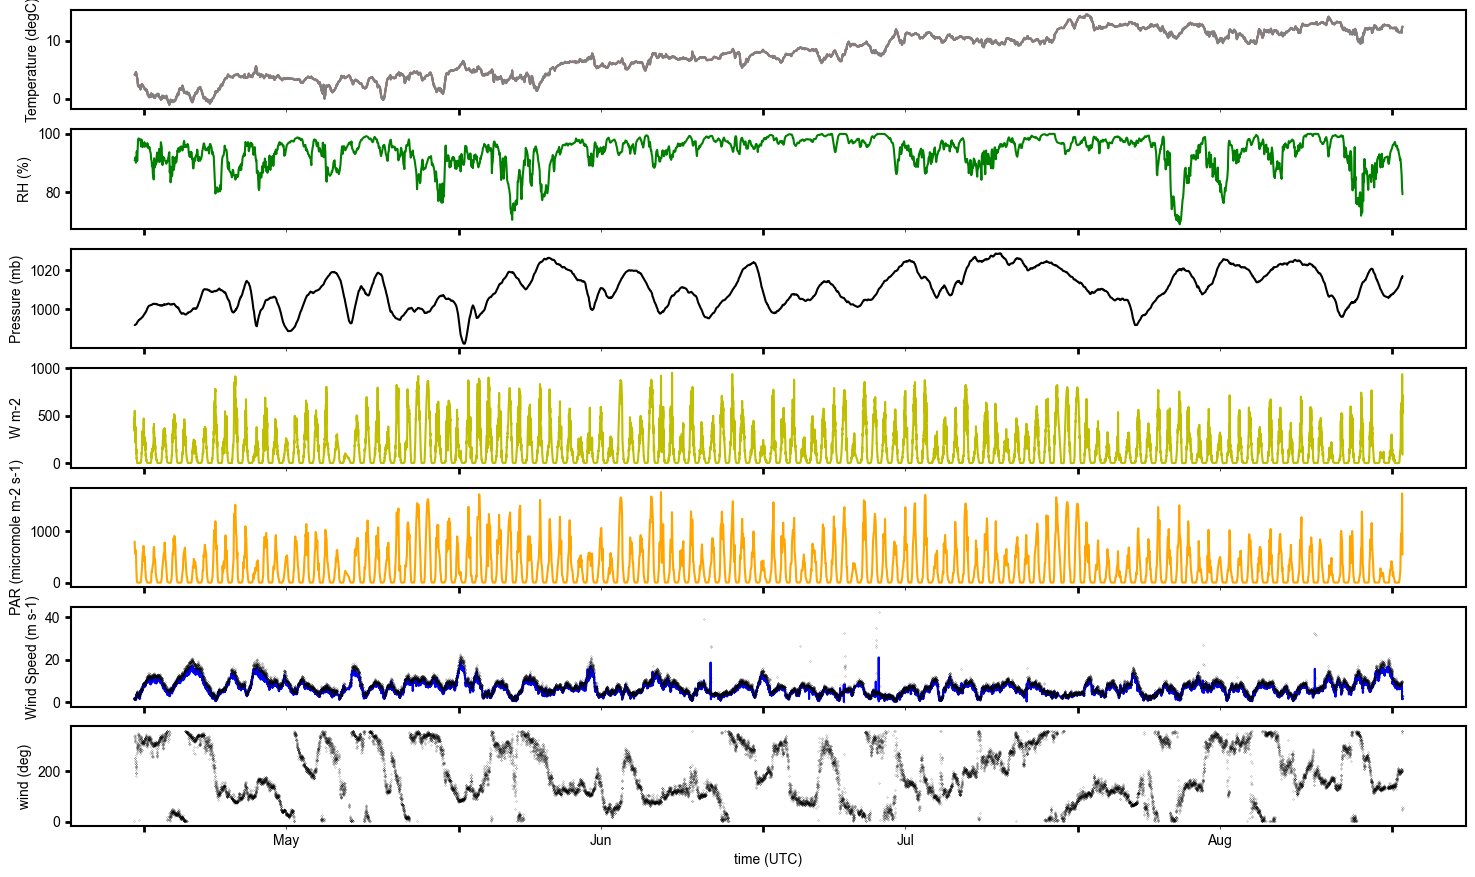

In [6]:
fig, ax = plt.subplots(7,figsize=(18, 12),sharex=True)
met_df.Air_Temp.dropna().plot(ax=ax[0],c='r')
(met_df.Air_Temp.dropna()+met_df.Air_Temp_Std.dropna()).plot(ax=ax[0],c='grey')
(met_df.Air_Temp.dropna()-met_df.Air_Temp_Std.dropna()).plot(ax=ax[0],c='grey')
ax[0].set_ylabel('Temperature (degC)')
met_df.RH.dropna().plot(ax=ax[1],c='g')
ax[1].set_ylabel('RH (%)')
met_df.BaroPres.dropna().plot(ax=ax[2],c='k')
ax[2].set_ylabel('Pressure (mb)')
met_df.ShortWaveRad.dropna().plot(ax=ax[3],c='y')
ax[3].set_ylabel('W m-2')
met_df.PAR.dropna().plot(ax=ax[4],c='orange')
ax[4].set_ylabel('PAR (micromole m-2 s-1)')
met_df['Wind_Speed'].dropna().plot(ax=ax[5],c='b')
met_df['Gust'].dropna().plot(ax=ax[5],c='k',style='.',markersize=.25)
ax[5].set_ylabel('Wind Speed (m s-1)')
met_df['wind_from_direction'].dropna().plot(ax=ax[6],c='k',style='.',markersize=.25)
ax[6].set_ylabel('wind (deg)')

ax[2].xaxis.set_minor_locator(DayLocator(bymonthday=15))
ax[2].xaxis.set_major_locator(DayLocator(bymonthday=1))
ax[2].xaxis.set_minor_formatter(DateFormatter('%b'))
ax[2].xaxis.set_major_formatter(DateFormatter(''))

In [7]:
## Modify the raw file for whatever remaing QC you want to apply

In [8]:
## change variable names if needed to match TELOS yaml expectations

In [9]:
met_df.index = met_df.index.rename('date_time')
met_df = met_df.rename(columns={'BaroPres':'pressure',
                                'Temperature':'PAR_Temp',
                                  'Air_Temp':'temperature',
                                  'U_wind':'northward_wind',
                                  'V_wind':'eastward_wind',
                                  'Wind_Speed':'wind_speed_',
                                  'Gust':'wind_speed_gust',
                                  'RH':'relative_humidity',
                                'wind_from_direction':'wind_direction',
                                'ShortWaveRad':'swrad',
                                'PAR':'par'
                                  })
met_df.sample()

,par,Pitch,Roll,PAR_Temp,pressure,BP_Std,temperature,Air_Temp_Std,relative_humidity,RH_Std,swrad,northward_wind,Uwind_Std,eastward_wind,Vwind_Std,wind_speed_,wind_speed_gust,Compass,wind_speed,wind_direction
date_time,,,,,,,,,,,,,,,,,,,,
2025-08-18 19:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.66,-4.7,1.9,-5.7,1.8,7.9,8.9,20.3,7.387828,39.507675


## Add Deployment meta information

Two methods are available (if comming from python2 world - ordereddict was important... in py38 a dictionary is inherently ordered)

In [10]:
#just a dictionary of dictionaries - simple
with open(mooring_meta_file) as file:
    mooring_config = yaml.full_load(file)

In [11]:
#just a dictionary of dictionaries - simple
with open(institution_meta_file) as file:
    institution_config = yaml.full_load(file)

In [12]:
with open(inst_meta_file) as file:
    inst_config = yaml.full_load(file)

In [13]:
# Add meta data and prelim processing based on meta data
# Convert to xarray and add meta information - save as CF netcdf file
# pass -> data, instmeta, depmeta
met_wop_nc = ncCFsave.EcoFOCI_CFnc(df=met_df, 
                                instrument_yaml=inst_config, 
                                operation_yaml=mooring_config,
                                operation_type='mooring', 
                                instrument_id=instrument, 
                                inst_shortname=inst_shortname)
met_wop_nc

At this point, you could save your file with the `.xarray2netcdf_save()` method and have a functioning dataset.... but it would be very simple with no additional qc, meta-data, or tuned parameters for optimizing software like ferret or erddap.

In [14]:
# expand the dimensions and coordinate variables
# renames them appropriatley and prepares them for meta-filled values
met_wop_nc.expand_dimensions()

In [15]:
met_wop_nc.variable_meta_data(variable_keys=list(met_df.columns.values),drop_missing=True)
# met_wop_nc.temporal_geospatioal_meta_data(depth='actual')
#adding dimension meta needs to come after updating the dimension values... BUG?
met_wop_nc.dimension_meta_data(variable_keys=['depth','latitude','longitude'])

The following steps can happen in just about any order and are all meta-data driven.  Therefore, they are not required to have a functioning dataset, but they are required to have a well described dataset

In [16]:
#add global attributes
met_wop_nc.deployment_meta_add()
met_wop_nc.get_xdf()

#add instituitonal global attributes
met_wop_nc.institution_meta_add(institution_yaml=institution_config)

#add instrument global attributes
# met_wop_nc.instrument_meta_data()

#add creation date/time - provenance data
met_wop_nc.provinance_meta_add()

#provide intial qc status field
met_wop_nc.qc_status(qc_status='unknown')

In [17]:
met_wop_nc.get_xdf()

<xarray.Dataset> Size: 1MB
Dimensions:            (time: 18000, depth: 1, latitude: 1, longitude: 1)
Coordinates:
  * time               (time) datetime64[ns] 144kB 2025-04-30T00:20:00 ... 20...
  * depth              (depth) float64 8B 1e+35
  * latitude           (latitude) float64 8B 1e+35
  * longitude          (longitude) float64 8B 1e+35
Data variables:
    par                (time, depth, latitude, longitude) float64 144kB nan ....
    pressure           (time, depth, latitude, longitude) float64 144kB nan ....
    temperature        (time, depth, latitude, longitude) float64 144kB nan ....
    relative_humidity  (time, depth, latitude, longitude) float64 144kB nan ....
    swrad              (time, depth, latitude, longitude) float64 144kB 481.4...
    northward_wind     (time, depth, latitude, longitude) float64 144kB -0.1 ...
    eastward_wind      (time, depth, latitude, longitude) float64 144kB -1.6 ...
    wind_speed         (time, depth, latitude, longitude) float64 144kB 1.603...
    wind_direction     (time, depth, latitude, longitude) float64 144kB 3.576...
Attributes: (12/28)
    MooringID:                              25BSPR-2A
    platform_deployment_date:               2025-04-30T00:40:00Z
    platform_deployment_cruise_name:        DY2504
    platform_recovery_date:                 2025-08-30T22:40:00Z
    platform_recovery_cruise_name:          
    platform_deployment_recovery_comments:  remove 0.75m ss above RCMSG
\nPra...
    ...                                     ...
    references:                             
    citation:                               
    acknowledgement:                        
    date_created:                           2026-02-02T14:38:28Z
    date_modified:                          
    QC_indicator:                           unknown

## Save CF Netcdf files

Currently stick to netcdf3 classic... but migrating to netcdf4 (default) may be no problems for most modern purposes.  Its easy enough to pass the `format` kwargs through to the netcdf api of xarray.

In [18]:
# combine trim (not mandatory) and filename together (saves to test.nc without name)

depth = ''
# mooring_yaml['Instrumentation'][self.instrument_id]['DesignedDepth'])).zfill(4) #<-- alternative
filename = "".join(mooring_config['MooringID'].split('-')).lower()+'_'+inst_shortname+'.nc'
met_wop_nc.xarray2netcdf_save(xdf = met_wop_nc.autotrim_time(),
                           filename=filename,format="NETCDF3_CLASSIC")

# don't trim the data and pass your own filename
# sbe37_wop_nc.xarray2netcdf_save(xdf = sbe37_wop_nc.get_xdf(),
#                            filename=filename,format="NETCDF4_CLASSIC")

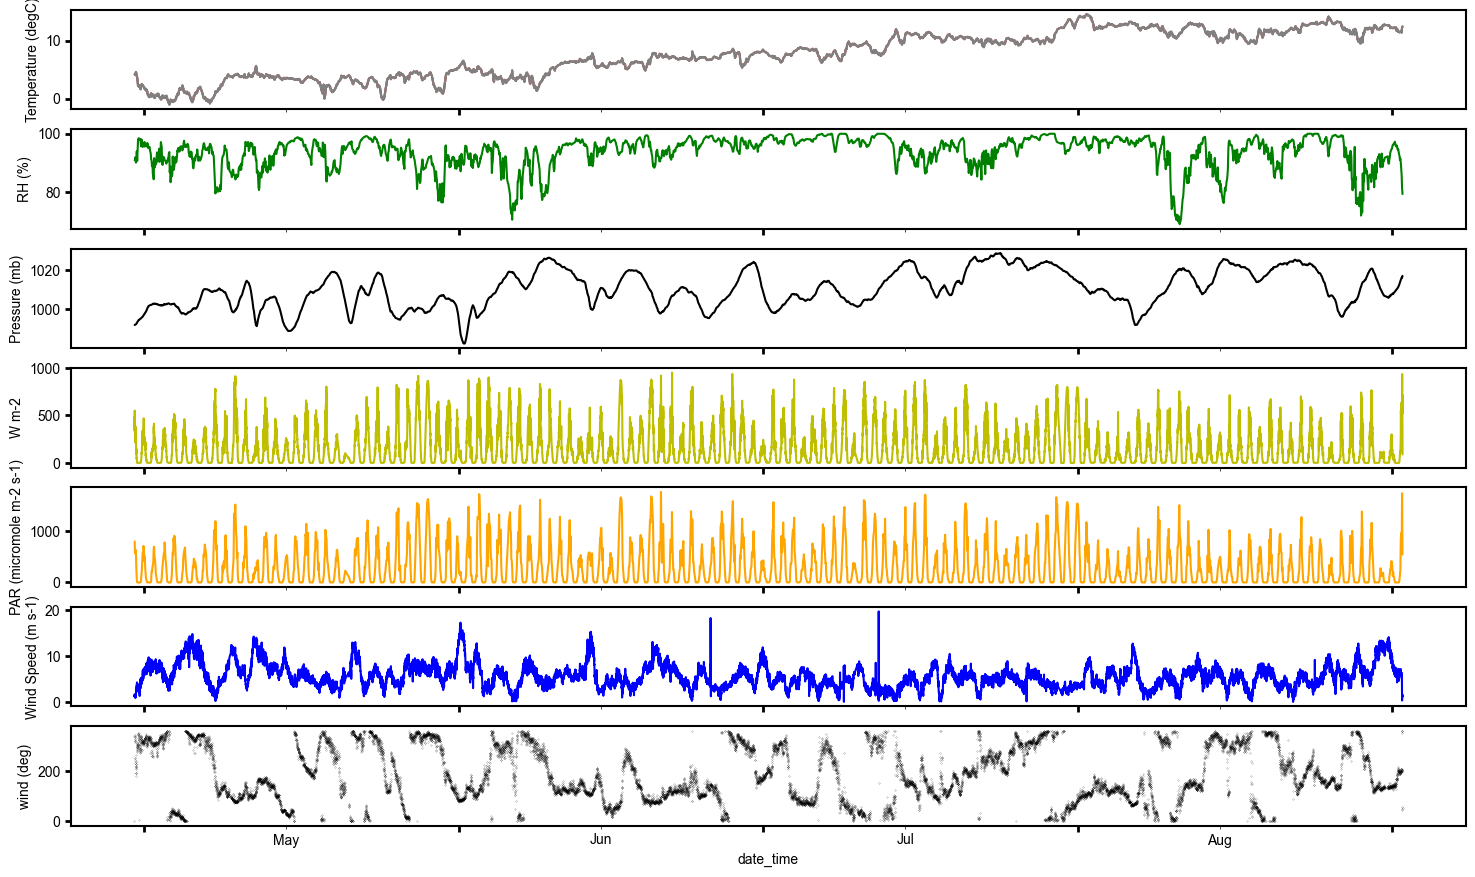

In [19]:
fig, ax = plt.subplots(7,figsize=(18, 12),sharex=True)
met_df.temperature.dropna().plot(ax=ax[0],c='r')
(met_df.temperature.dropna()+met_df.Air_Temp_Std.dropna()).plot(ax=ax[0],c='grey')
(met_df.temperature.dropna()-met_df.Air_Temp_Std.dropna()).plot(ax=ax[0],c='grey')
ax[0].set_ylabel('Temperature (degC)')
met_df.relative_humidity.dropna().plot(ax=ax[1],c='g')
ax[1].set_ylabel('RH (%)')
met_df.pressure.dropna().plot(ax=ax[2],c='k')
ax[2].set_ylabel('Pressure (mb)')
met_df.swrad.dropna().plot(ax=ax[3],c='y')
ax[3].set_ylabel('W m-2')
met_df.par.dropna().plot(ax=ax[4],c='orange')
ax[4].set_ylabel('PAR (micromole m-2 s-1)')
met_df['wind_speed'].dropna().plot(ax=ax[5],c='b')
# met_df['Gust'].dropna().plot(ax=ax[5],c='k',style='.',markersize=.25)
ax[5].set_ylabel('Wind Speed (m s-1)')
met_df['wind_direction'].dropna().plot(ax=ax[6],c='k',style='.',markersize=.25)
ax[6].set_ylabel('wind (deg)')

ax[2].xaxis.set_minor_locator(DayLocator(bymonthday=15))
ax[2].xaxis.set_major_locator(DayLocator(bymonthday=1))
ax[2].xaxis.set_minor_formatter(DateFormatter('%b'))
ax[2].xaxis.set_major_formatter(DateFormatter(''))

fig.savefig(f"images/{filename.replace('nc','fullres_met.png')}")